# Discounting Models

This notebook demonstrates a family of discounting models, all sharing the
same generative shape: a binary choice between a "baseline" option
(undiscounted) and a "discounted" option whose value shrinks as a function
of a block-level discounting variable, with choice given by a logistic
(sigmoid) function of the value difference. All models are defined in
`pyem/models/discounting.py`.

Five discounting domains are covered, each its own subsection below:

- **Social discounting** -- distance to a social target (`sd_*`)
- **Temporal (delay) discounting** -- delay until a larger reward (`td_*`)
- **Probability discounting** -- odds against a risky reward (`prd_*`)
- **Effort discounting** -- physical/cognitive effort cost (`ed_*`)
- **Prosocial effort discounting** -- effort exerted for self vs other (`ped_*`)

In every task, the **discounted option carries the larger reward** and the
**baseline option a smaller reward that steps down a 9-rung ladder**. As the
block-level discounting variable grows, the discounted option's value falls
and the indifference point sweeps down the ladder. This makes the
discount rate $k$ recoverable at every block level.

## Social Discounting

### Task

On every trial, the participant chooses between two options:

- **Selfish**: keep the whole pot, the target gets nothing.
- **Prosocial**: split the pot with the target.

The same 9-trial payout ladder repeats at each of 7 social distances,
`N = [1, 2, 5, 10, 20, 50, 100]` (1 = closest, e.g. a partner or close
friend; 100 = most distant, e.g. a stranger), for 7 blocks x 9 trials = 63
trials total per subject.

**TASK1** holds the prosocial split fixed at $r_{\text{self}}=75$, $r_{\text{other}}=75$,
and steps the selfish option's $r_{\text{self}}$ down from \$155 to \$75 across the 9
trials. The "cost" of choosing prosocial over selfish shrinks from \$80 (give
up \$155 for \$75) to \$0 (the two options are identical) as the ladder
descends.

**TASK2** holds the prosocial split fixed at $r_{\text{self}}=0$, $r_{\text{other}}=105$
(choosing prosocial always means giving up everything yourself), and steps
the selfish option's $r_{\text{self}}$ down from \$95 to \$15. Unlike TASK1, the
prosocial option here never benefits the chooser at all; only the
opportunity cost of staying selfish shrinks.

Below, `payouts[trial, choice, target]` with `choice = 0` selfish / `1`
prosocial, and `target = 0` self / `1` other -- i.e. `payouts[..., 0]` is
$r_{\text{self}}$ and `payouts[..., 1]` is $r_{\text{other}}$ for that option.

### Model

On each trial, the value of an option is the chooser's own payout $r_{\text{self}}$
plus a (weighted, distance-discounted) value of the target's payout $r_{\text{other}}$:

$$
\textbf{Self utility:}\quad U_{\text{self}} = r_{\text{self}}
$$

$$
\textbf{Weighted target reward:}\quad R = w_{\text{other}} \cdot r_{\text{other}}
$$

$w_{\text{other}}$ is an **other-regarding weight** ($w_{\text{other}}=1$ values the
target's dollar the same as the chooser's own, $<1$ undervalues it, $>1$
overvalues it; fixed at 1 except in `sd_hyp_wk`, where it's free). $R$ is
then discounted as a function of social distance $N$, using one of three
shapes:

$$
\textbf{Hyperbolic:}\quad U_{\text{other}}(N) = \frac{R}{1+kN}
$$

$$
\textbf{Linear:}\quad U_{\text{other}}(N) = R - kN \quad \text{(only where } R>0\text{, else } 0\text{)}
$$

$$
\textbf{Parabolic:}\quad U_{\text{other}}(N) = R - kN^2 \quad \text{(only where } R>0\text{, else } 0\text{)}
$$

The "only where $R>0$" clause matters: the selfish option always has
$r_{\text{other}}=0$, so $R=0$ for it regardless of $N$. Hyperbolic discounting
handles this for free ($0/\text{anything}=0$), but a bare subtractive form
would inject a $-kN$ penalty into the selfish option too, which cancels out
of the option comparison below and makes $N$ irrelevant to choice. Gating
the subtraction on $R>0$ keeps "nothing offered" equal to "nothing
discounted" for every shape.

Total option value: $V = U_{\text{self}} + U_{\text{other}}$.

$$
\textbf{Choice rule (logistic / sigmoid):}\quad
p(\text{prosocial}) = \sigma\big(\Delta V\big) = \frac{1}{1+e^{-\left(V_{\text{prosocial}} - V_{\text{selfish}}\right)}}
$$

This is the standard logistic choice function used in the discounting
literature (equivalent to a two-option softmax with unit temperature): there
is **no free inverse temperature**. Since the selfish option always offers
the target nothing, the comparison reduces to

$$
\Delta V = \frac{w_{\text{other}} \cdot r_{\text{other}}}{1+kN} - r_{\text{self}}
$$

for the hyperbolic models, where $r_{\text{self}}$ here is the selfish
option's own payout minus the prosocial option's own payout.

Four model variants are defined in `pyem/models/discounting.py`:

| model | discount shape | free parameters |
|---|---|---|
| `sd_hyp_wk` | hyperbolic | $w_{\text{other}}$, $k$ |
| `sd_hyp_k`  | hyperbolic | $k$ ($w_{\text{other}}=1$) |
| `sd_par_k`  | parabolic  | $k$ ($w_{\text{other}}=1$) |
| `sd_lin_k`  | linear     | $k$ ($w_{\text{other}}=1$) |

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import truncnorm
from scipy.special import expit

from pyem import EMModel
from pyem.utils.math import norm2beta
from pyem.utils import plotting

from pyem.models.discounting import (
    # social discounting
    TASK1_PAYOUTS, TASK2_PAYOUTS, DEFAULT_SOCIAL_DISTS,
    sd_hyp_wk_model, sd_hyp_k_model, sd_par_k_model, sd_lin_k_model,
    # temporal (delay) discounting
    TD_PAYOUTS, DEFAULT_DELAYS, td_hyp_k_model,
    # probability discounting
    PRD_PAYOUTS, DEFAULT_PROBS, prd_hyp_k_model,
    # effort discounting (parabolic)
    ED_PAYOUTS, DEFAULT_EFFORT_LEVELS, ed_par_k_model,
    # prosocial effort discounting (parabolic; single-k and self/other-k)
    PED_PAYOUTS, PED_EFFORT_LEVELS, PED_BENEFICIARY,
    ped_par_k_model, ped_par_2k_model,
)

rng = np.random.default_rng(2026)

def draw_positive(n, lo, hi, loc=0.0, scale=1.0):
    # truncated-normal draw restricted to [lo, hi]
    a = (lo - loc) / scale
    b = (hi - loc) / scale
    return truncnorm(a, b, loc=loc, scale=scale).rvs(n, random_state=rng)

nsubjects = 100

In [2]:
# choose task for the recovery runs below
payouts = TASK1_PAYOUTS.copy()
# payouts = TASK2_PAYOUTS.copy()

social_dists = DEFAULT_SOCIAL_DISTS.copy()

# k ranges differ by discount shape: N reaches 100, and k*N (linear) or
# k*N**2 (parabolic) both need to land in roughly the same dollar range as
# the payouts themselves (~0-150) for the discount to actually bite without
# saturating every trial's choice probability.
wmin, wmax = 0.2, 2.0
k_ranges = {
    "hyperbolic": (0.001, 0.25),
    "linear":     (0.05, 1.5),
    "parabolic":  (0.0005, 0.015),
}
k_scales = {
    "hyperbolic": 0.08,
    "linear":     0.5,
    "parabolic":  0.005,
}

#### Hyperbolic discounting, 2 parameters ($w_{\text{other}}$, $k$) — `sd_hyp_wk`

$$
V = r_{\text{self}} + \frac{w_{\text{other}} \cdot r_{\text{other}}}{1+kN}, \qquad p(\text{prosocial}) = \sigma\big(V_{\text{prosocial}} - V_{\text{selfish}}\big)
$$

In [3]:
print(f"Model ID   : {sd_hyp_wk_model.id}")
print(f"Description: {sd_hyp_wk_model.desc}")
print(f"Spec       : {sd_hyp_wk_model.spec}")

Model ID   : sd_hyp_wk
Description: Hyperbolic social discounting: U_other(N) = w_other*r_other / (1 + k*N).
The other-regarding weight is applied to the target's payoff, then discounted
hyperbolically as a function of social distance N.
p(prosocial) = sigmoid(V_prosocial - V_selfish).
Free parameters: w_other (other-regarding weight, >0), k (hyperbolic discount rate, >0).
Spec       : {'social_discounting': {'weight': ['w_other'], 'discount': ['k']}, 'shape': 'hyperbolic', 'choice_rule': 'sigmoid(delta_V)'}


799.3094 (000), 364.2788 (001), 325.3406 (002), 324.5119 (003), 324.4981 (004), 

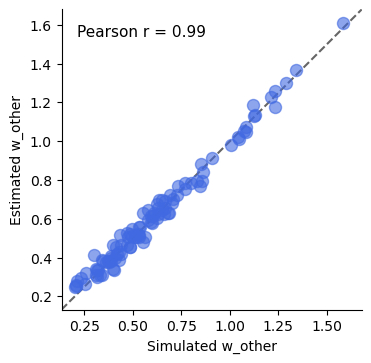

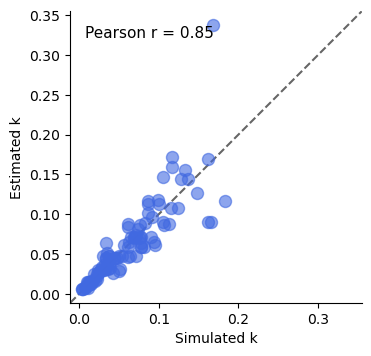

In [4]:
kmin, kmax = k_ranges["hyperbolic"]
true_w_other = draw_positive(nsubjects, wmin, wmax, loc=0.0, scale=0.6)
true_k = draw_positive(nsubjects, kmin, kmax, loc=0.0, scale=k_scales["hyperbolic"])
true_params = np.stack([true_w_other, true_k], axis=1)

sim = sd_hyp_wk_model.sim(true_params, payouts=payouts, social_dists=social_dists)
all_data = [[c, p, d] for c, p, d in zip(sim["choices"], sim["payouts"], sim["social_dists"])]

model = EMModel(
    all_data=all_data,
    fit_func=sd_hyp_wk_model.fit,
    param_names=["w_other", "k"],
    param_xform=[norm2beta, norm2beta],
)

result = model.fit(verbose=1)

for param_idx, param_label in enumerate(["w_other", "k"]):
    simulated_param = sim["params"][:, param_idx]
    estimated_param = model.outfit["params"][:, param_idx]
    ax = plotting.plot_scatter(simulated_param, f"Simulated {param_label}",
                                estimated_param, f"Estimated {param_label}")

Diagnostic plots: the fitted value difference ($\Delta V$ = prosocial minus
selfish) and the discounted utility of the target's payout ($U_{\text{other}}$),
as a function of social distance $N$ and the selfish option's own payout
$r_{\text{self}}$. (Built from `TASK1_PAYOUTS`; swap in `TASK2_PAYOUTS` if you
changed `payouts` above.)

In [5]:
_, nblocks, ntrials = model.outfit['delta_V'].shape
df = pd.DataFrame({
    "subj_idx": np.repeat(np.arange(nsubjects), nblocks * ntrials),
    "social distance (N)": np.repeat(model.outfit['social_dists'].reshape(-1), ntrials),
    "trial_idx": np.tile(np.arange(ntrials), nsubjects * nblocks),
    "value (prosocial - selfish)": model.outfit['delta_V'].reshape(-1),
    "prosocial choice": model.outfit['choices_prosocial'].reshape(-1),
    "utility (other)": model.outfit['U_other'].reshape(-1),
    "r_self": np.tile(TASK1_PAYOUTS[:, 0, 0, ...], nsubjects * nblocks),
    "p(prosocial)": model.outfit['p_prosocial'].reshape(-1),
})

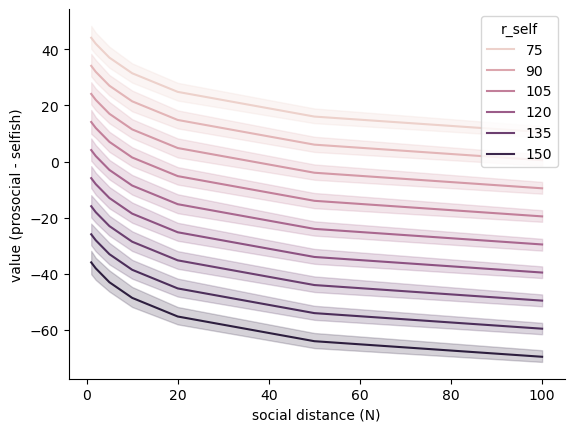

In [6]:
sns.lineplot(data=df, x='social distance (N)', y='value (prosocial - selfish)', hue='r_self')
sns.despine()

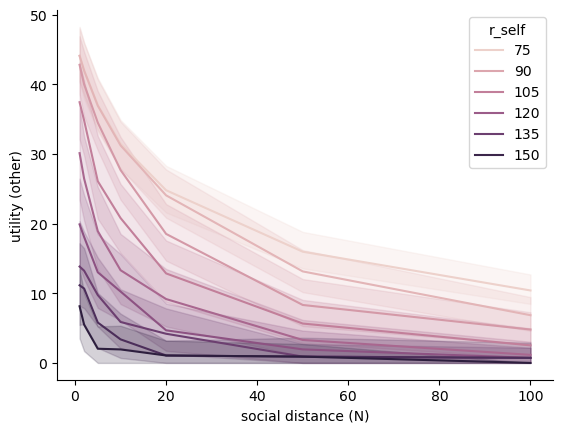

In [7]:
sns.lineplot(data=df, y='utility (other)', x='social distance (N)', hue='r_self')
sns.despine()

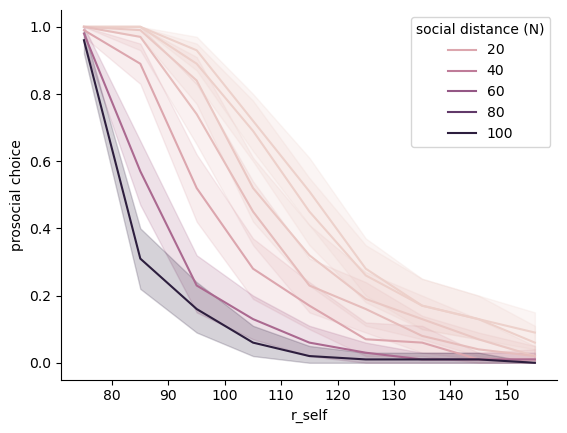

In [8]:
sns.lineplot(x='r_self', y='prosocial choice', hue='social distance (N)', data=df)
sns.despine()

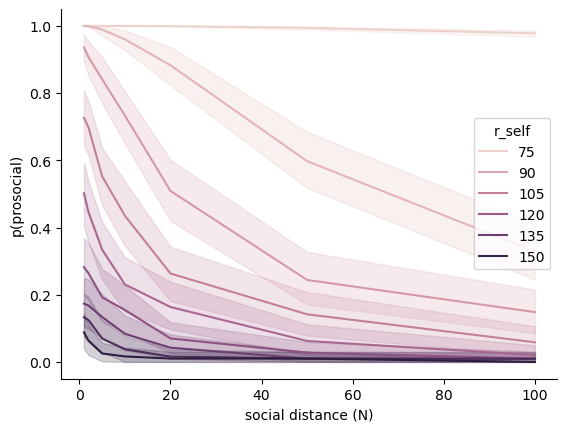

In [9]:
sns.lineplot(data=df, y='p(prosocial)', x='social distance (N)', hue='r_self')
sns.despine()

<hr width="80%">

#### Hyperbolic discounting, 1 parameter ($k$; $w_{\text{other}}=1$) — `sd_hyp_k`

$$
V = r_{\text{self}} + \frac{r_{\text{other}}}{1+kN}, \qquad p(\text{prosocial}) = \sigma\big(V_{\text{prosocial}} - V_{\text{selfish}}\big)
$$

In [10]:
print(f"Model ID   : {sd_hyp_k_model.id}")
print(f"Description: {sd_hyp_k_model.desc}")
print(f"Spec       : {sd_hyp_k_model.spec}")

Model ID   : sd_hyp_k
Description: Hyperbolic social discounting: U_other(N) = r_other / (1 + k*N).
The target's payoff is discounted hyperbolically as a function of social
distance N (w_other fixed at 1). p(prosocial) = sigmoid(V_prosocial - V_selfish).
Free parameter: k (hyperbolic discount rate, >0).
Spec       : {'social_discounting': {'weight': [], 'discount': ['k']}, 'shape': 'hyperbolic', 'choice_rule': 'sigmoid(delta_V)'}


511.1793 (000), 369.5015 (001), 315.9170 (002), 315.8195 (003), 315.8102 (004), 315.8100 (007), 315.8098 (008), 

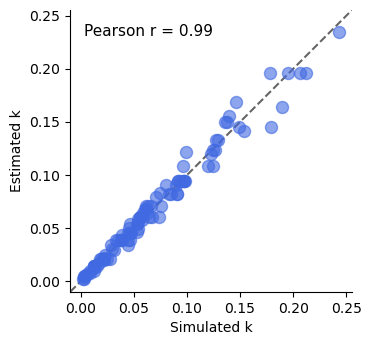

In [11]:
kmin, kmax = k_ranges["hyperbolic"]
true_k = draw_positive(nsubjects, kmin, kmax, loc=0.0, scale=k_scales["hyperbolic"])
true_params = np.stack([true_k], axis=1)

sim = sd_hyp_k_model.sim(true_params, payouts=payouts, social_dists=social_dists)
all_data = [[c, p, d] for c, p, d in zip(sim["choices"], sim["payouts"], sim["social_dists"])]

model = EMModel(
    all_data=all_data,
    fit_func=sd_hyp_k_model.fit,
    param_names=["k"],
    param_xform=[norm2beta],
)

result = model.fit(verbose=1)

for param_idx, param_label in enumerate(["k"]):
    simulated_param = sim["params"][:, param_idx]
    estimated_param = model.outfit["params"][:, param_idx]
    ax = plotting.plot_scatter(simulated_param, f"Simulated {param_label}",
                                estimated_param, f"Estimated {param_label}")

Same diagnostic plots as above, run on this recovery.

In [12]:
_, nblocks, ntrials = model.outfit['delta_V'].shape
df = pd.DataFrame({
    "subj_idx": np.repeat(np.arange(nsubjects), nblocks * ntrials),
    "social distance (N)": np.repeat(model.outfit['social_dists'].reshape(-1), ntrials),
    "trial_idx": np.tile(np.arange(ntrials), nsubjects * nblocks),
    "value (prosocial - selfish)": model.outfit['delta_V'].reshape(-1),
    "prosocial choice": model.outfit['choices_prosocial'].reshape(-1),
    "utility (other)": model.outfit['U_other'].reshape(-1),
    "r_self": np.tile(TASK1_PAYOUTS[:, 0, 0, ...], nsubjects * nblocks),
    "p(prosocial)": model.outfit['p_prosocial'].reshape(-1),
})

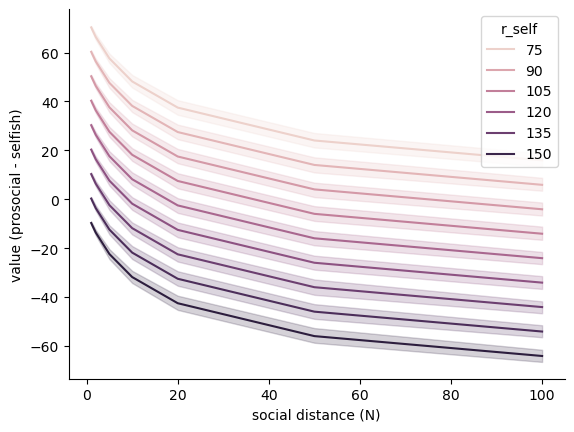

In [13]:
sns.lineplot(data=df, x='social distance (N)', y='value (prosocial - selfish)', hue='r_self')
sns.despine()

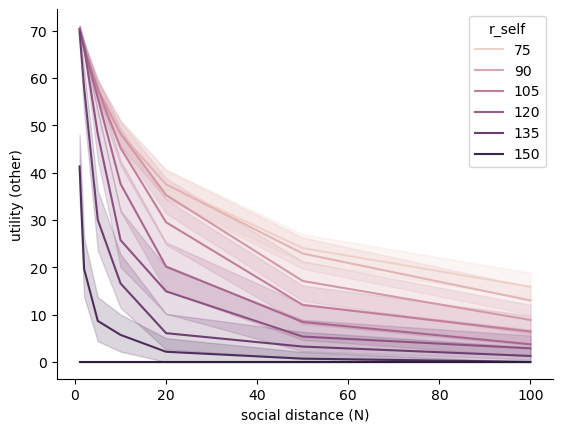

In [14]:
sns.lineplot(data=df, y='utility (other)', x='social distance (N)', hue='r_self')
sns.despine()

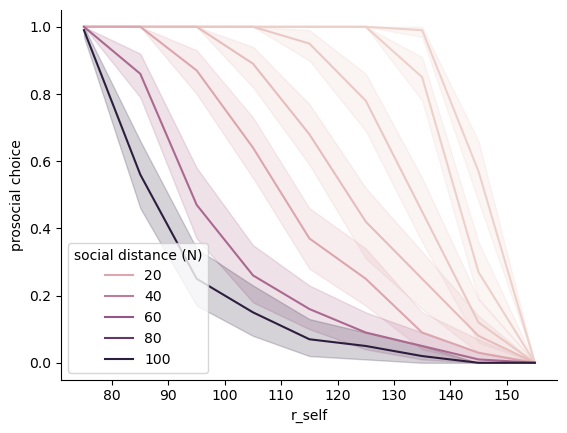

In [15]:
sns.lineplot(x='r_self', y='prosocial choice', hue='social distance (N)', data=df)
sns.despine()

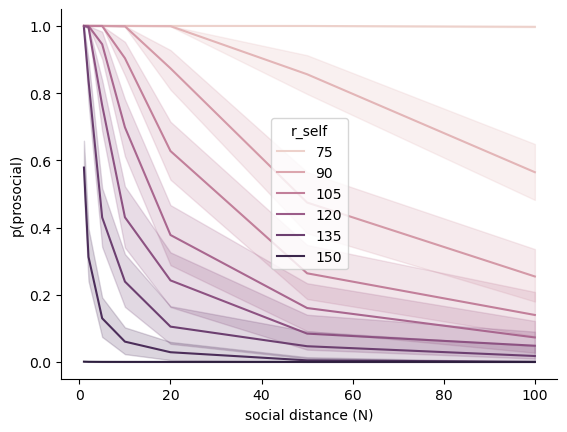

In [16]:
sns.lineplot(data=df, y='p(prosocial)', x='social distance (N)', hue='r_self')
sns.despine()

<hr width="80%">

#### Parabolic discounting, 1 parameter ($k$; $w_{\text{other}}=1$) — `sd_par_k`

$$
U_{\text{other}}(N) = r_{\text{other}} - kN^2 \quad \text{(only where } r_{\text{other}} > 0\text{)}, \qquad p(\text{prosocial}) = \sigma\big(V_{\text{prosocial}} - V_{\text{selfish}}\big)
$$

$N^2$ grows fast (up to $100^2=10{,}000$ at the farthest distance), so $k$
here needs to be roughly two orders of magnitude smaller than in the linear
model to produce a comparable amount of discounting.

In [17]:
print(f"Model ID   : {sd_par_k_model.id}")
print(f"Description: {sd_par_k_model.desc}")
print(f"Spec       : {sd_par_k_model.spec}")

Model ID   : sd_par_k
Description: Parabolic social discounting: U_other(N) = r_other - k*N**2 (for the
option that actually offers the target something; 0 for the selfish option,
regardless of N; w_other fixed at 1). p(prosocial) = sigmoid(V_prosocial - V_selfish).
Because N**2 grows fast, k must be much smaller than in the linear model to
produce comparable discounting over the same N range.
Free parameter: k (parabolic discount rate, >0).
Spec       : {'social_discounting': {'weight': [], 'discount': ['k']}, 'shape': 'parabolic', 'choice_rule': 'sigmoid(delta_V)'}


418.9663 (000), 210.6126 (001), 161.7512 (002), 159.5496 (003), 159.4082 (004), 159.3911 (005), 159.3884 (006), 159.3879 (007), 

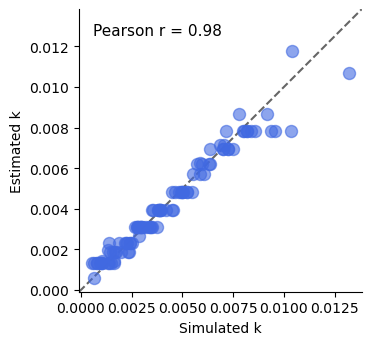

In [18]:
kmin, kmax = k_ranges["parabolic"]
true_k = draw_positive(nsubjects, kmin, kmax, loc=0.0, scale=k_scales["parabolic"])
true_params = np.stack([true_k], axis=1)

sim = sd_par_k_model.sim(true_params, payouts=payouts, social_dists=social_dists)
all_data = [[c, p, d] for c, p, d in zip(sim["choices"], sim["payouts"], sim["social_dists"])]

model = EMModel(
    all_data=all_data,
    fit_func=sd_par_k_model.fit,
    param_names=["k"],
    param_xform=[norm2beta],
)

result = model.fit(verbose=1)

for param_idx, param_label in enumerate(["k"]):
    simulated_param = sim["params"][:, param_idx]
    estimated_param = model.outfit["params"][:, param_idx]
    ax = plotting.plot_scatter(simulated_param, f"Simulated {param_label}",
                                estimated_param, f"Estimated {param_label}")

<hr width="80%">

#### Linear discounting, 1 parameter ($k$; $w_{\text{other}}=1$) — `sd_lin_k`

$$
U_{\text{other}}(N) = r_{\text{other}} - kN \quad \text{(only where } r_{\text{other}} > 0\text{)}, \qquad p(\text{prosocial}) = \sigma\big(V_{\text{prosocial}} - V_{\text{selfish}}\big)
$$

In [19]:
print(f"Model ID   : {sd_lin_k_model.id}")
print(f"Description: {sd_lin_k_model.desc}")
print(f"Spec       : {sd_lin_k_model.spec}")

Model ID   : sd_lin_k
Description: Linear social discounting: U_other(N) = r_other - k*N (for the option
that actually offers the target something; 0 for the selfish option,
regardless of N; w_other fixed at 1). p(prosocial) = sigmoid(V_prosocial - V_selfish).
Utility is not floored at zero, so heavily-discounted prosocial offers can
carry negative utility at large N.
Free parameter: k (linear discount rate, >0).
Spec       : {'social_discounting': {'weight': [], 'discount': ['k']}, 'shape': 'linear', 'choice_rule': 'sigmoid(delta_V)'}


445.8052 (000), 235.5397 (001), 232.9822 (002), 232.8182 (003), 232.7963 (004), 232.7925 (005), 232.7918 (006), 

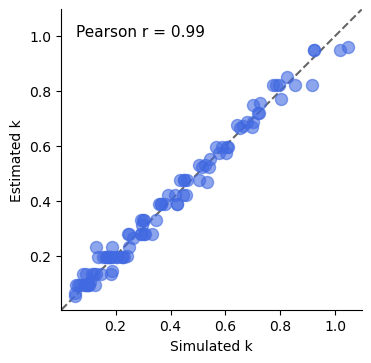

In [20]:
kmin, kmax = k_ranges["linear"]
true_k = draw_positive(nsubjects, kmin, kmax, loc=0.0, scale=k_scales["linear"])
true_params = np.stack([true_k], axis=1)

sim = sd_lin_k_model.sim(true_params, payouts=payouts, social_dists=social_dists)
all_data = [[c, p, d] for c, p, d in zip(sim["choices"], sim["payouts"], sim["social_dists"])]

model = EMModel(
    all_data=all_data,
    fit_func=sd_lin_k_model.fit,
    param_names=["k"],
    param_xform=[norm2beta],
)

result = model.fit(verbose=1)

for param_idx, param_label in enumerate(["k"]):
    simulated_param = sim["params"][:, param_idx]
    estimated_param = model.outfit["params"][:, param_idx]
    ax = plotting.plot_scatter(simulated_param, f"Simulated {param_label}",
                                estimated_param, f"Estimated {param_label}")

<hr width="100%" style="border-top: 3px solid; margin: 2em 0;">

## Temporal (Delay) Discounting

### Task

On every trial, the participant chooses between two options:

- **Sooner**: a **smaller** amount available **immediately**.
- **Later**: a **larger, fixed** amount (\$155) available after a delay of
  $D$ days.

This is the standard **smaller-sooner vs larger-later** paradigm. The same
9-trial ladder repeats at each of 7 delays,
`D = [1, 2, 5, 10, 20, 50, 100]` days, for 7 blocks x 9 trials = 63 trials
total per subject. `TD_PAYOUTS` fixes the later reward at \$155 and steps the
immediate sooner amount down from \$145 to \$25.

Only the **later** reward is delay-discounted; the immediate sooner reward is
received now and is **not** discounted. As the delay grows, the discounted
value of the later reward falls, so the sooner amount at which the two are
equally attractive sweeps down the ladder.

Below, `payouts[trial, choice]` with `choice = 0` sooner / `1` later -- a
single dollar amount per option (no self/other split, since there's no
social target here).

### Model

$$
V_{\text{sooner}} = r_{\text{sooner}} \quad\text{(immediate, undiscounted)}, \qquad V_{\text{later}}(D) = \frac{r_{\text{later}}}{1+kD}
$$

$$
p(\text{later}) = \sigma\big(V_{\text{later}} - V_{\text{sooner}}\big)
$$

Hyperbolic delay discounting (Mazur, 1987). One model, one free parameter:
`td_hyp_k` ($k$, the delay discount rate).

In [21]:
print(f"Model ID   : {td_hyp_k_model.id}")
print(f"Description: {td_hyp_k_model.desc}")
print(f"Spec       : {td_hyp_k_model.spec}")

Model ID   : td_hyp_k
Description: Hyperbolic temporal (delay) discounting (Mazur, 1987) in a
smaller-sooner vs larger-later task: V_later(D) = r_later / (1 + k*D), while
the smaller immediate 'sooner' reward is undiscounted (V_sooner = r_sooner).
p(later) = sigmoid(V_later - V_sooner).
Free parameter: k (delay discount rate, >0).
Spec       : {'temporal_discounting': {'weight': [], 'discount': ['k']}, 'shape': 'hyperbolic', 'choice_rule': 'sigmoid(delta_V)'}


416.5171 (000), 280.5804 (001), 196.1512 (002), 192.1735 (003), 192.1706 (004), 192.1689 (005), 192.1689 (006), 

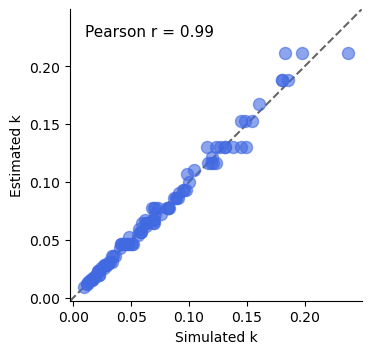

In [22]:
delays = DEFAULT_DELAYS.copy()
td_payouts = TD_PAYOUTS.copy()

# k*D must keep 155/(1+kD) sweeping the sooner-amount ladder across delays.
kmin, kmax = 0.006, 0.25
true_k = draw_positive(nsubjects, kmin, kmax, loc=0.0, scale=0.08)
true_params = np.stack([true_k], axis=1)

sim = td_hyp_k_model.sim(true_params, payouts=td_payouts, delays=delays)
all_data = [[c, p, d] for c, p, d in zip(sim["choices"], sim["payouts"], sim["delays"])]

model = EMModel(
    all_data=all_data,
    fit_func=td_hyp_k_model.fit,
    param_names=["k"],
    param_xform=[norm2beta],
)

result = model.fit(verbose=1)

for param_idx, param_label in enumerate(["k"]):
    simulated_param = sim["params"][:, param_idx]
    estimated_param = model.outfit["params"][:, param_idx]
    ax = plotting.plot_scatter(simulated_param, f"Simulated {param_label}",
                                estimated_param, f"Estimated {param_label}")

Diagnostic plots: the fitted value difference ($\Delta V$ = later minus
sooner) and the choice rate for the larger-later option, as a function of
delay $D$ and the sooner option's own amount $r_{\text{sooner}}$.

In [23]:
_, nblocks, ntrials = model.outfit['delta_V'].shape
df = pd.DataFrame({
    "subj_idx": np.repeat(np.arange(nsubjects), nblocks * ntrials),
    "delay (D, days)": np.repeat(model.outfit['delays'].reshape(-1), ntrials),
    "trial_idx": np.tile(np.arange(ntrials), nsubjects * nblocks),
    "value (later - sooner)": model.outfit['delta_V'].reshape(-1),
    "later choice": model.outfit['choices_later'].reshape(-1),
    "r_sooner": np.tile(TD_PAYOUTS[:, 0], nsubjects * nblocks),
})

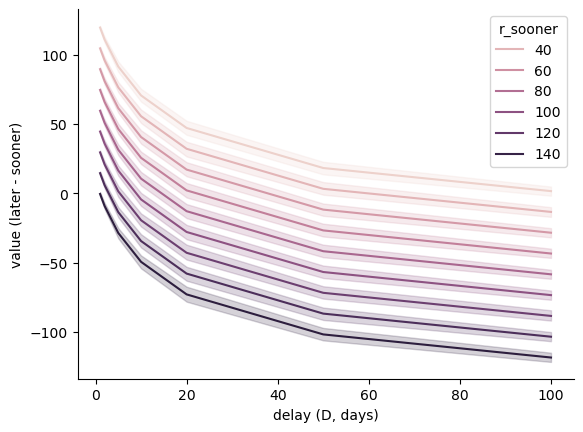

In [24]:
sns.lineplot(data=df, x='delay (D, days)', y='value (later - sooner)', hue='r_sooner')
sns.despine()

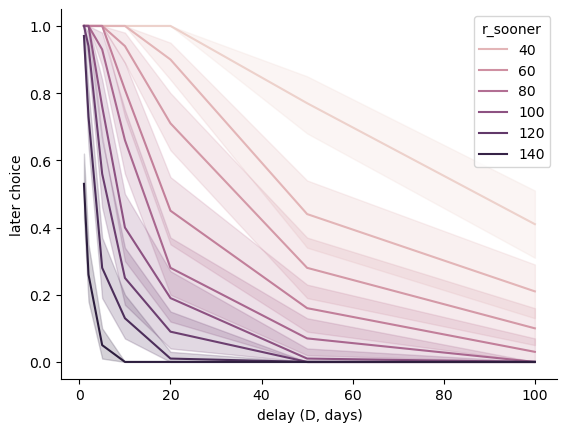

In [25]:
sns.lineplot(data=df, x='delay (D, days)', y='later choice', hue='r_sooner')
sns.despine()

<hr width="100%" style="border-top: 3px solid; margin: 2em 0;">

## Probability Discounting

### Task

On every trial, the participant chooses between two options:

- **Certain**: a **smaller** amount received **for sure**.
- **Risky**: a **larger, fixed** amount (\$155) received only with
  probability $p$.

The same 9-trial ladder repeats at each of 7 win probabilities,
`p = [0.95, 0.9, 0.75, 0.5, 0.25, 0.1, 0.05]` (0.95 = nearly certain; 0.05 =
a long shot), for 7 blocks x 9 trials = 63 trials total per subject.
`PRD_PAYOUTS` fixes the risky reward at \$155 and steps the certain amount
down from \$145 to \$25.

Only the **risky** reward is probability-discounted; the certain amount is a
sure thing and is not discounted. As $p$ falls, the discounted value of the
risky reward drops and the certain amount at indifference sweeps down the
ladder.

Below, `payouts[trial, choice]` with `choice = 0` certain / `1` risky.

### Model

$$
V_{\text{certain}} = r_{\text{certain}} \quad\text{(sure, undiscounted)}, \qquad V_{\text{risky}}(p) = \frac{r_{\text{risky}}}{1+k\theta}, \qquad \theta = \frac{1-p}{p}
$$

$$
p(\text{risky}) = \sigma\big(V_{\text{risky}} - V_{\text{certain}}\big)
$$

$\theta$ is the odds against winning; this is the classic hyperbolic
probability-discounting form (Rachlin, Raineri, & Cross, 1991). One model,
one free parameter: `prd_hyp_k` ($k$, the probability discount rate).

In [26]:
print(f"Model ID   : {prd_hyp_k_model.id}")
print(f"Description: {prd_hyp_k_model.desc}")
print(f"Spec       : {prd_hyp_k_model.spec}")

Model ID   : prd_hyp_k
Description: Hyperbolic probability discounting (Rachlin, Raineri, & Cross, 1991):
V_risky(p) = r_risky / (1 + k*theta), where theta = (1-p)/p is the odds
against winning; the smaller certain option is undiscounted.
p(risky) = sigmoid(V_risky - V_certain).
Free parameter: k (probability discount rate, >0).
Spec       : {'probability_discounting': {'weight': [], 'discount': ['k']}, 'shape': 'hyperbolic', 'choice_rule': 'sigmoid(delta_V)'}


427.8055 (000), 183.1456 (001), 182.9889 (002), 182.9862 (003), 182.9860 (004), 

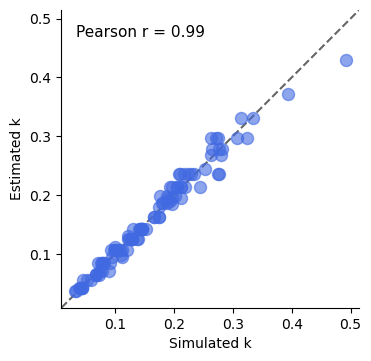

In [27]:
probs = DEFAULT_PROBS.copy()
prd_payouts = PRD_PAYOUTS.copy()

# k*theta must keep 155/(1+k*theta) sweeping the certain-amount ladder as p falls.
kmin, kmax = 0.03, 0.5
true_k = draw_positive(nsubjects, kmin, kmax, loc=0.0, scale=0.15)
true_params = np.stack([true_k], axis=1)

sim = prd_hyp_k_model.sim(true_params, payouts=prd_payouts, probs=probs)
all_data = [[c, p, d] for c, p, d in zip(sim["choices"], sim["payouts"], sim["probs"])]

model = EMModel(
    all_data=all_data,
    fit_func=prd_hyp_k_model.fit,
    param_names=["k"],
    param_xform=[norm2beta],
)

result = model.fit(verbose=1)

for param_idx, param_label in enumerate(["k"]):
    simulated_param = sim["params"][:, param_idx]
    estimated_param = model.outfit["params"][:, param_idx]
    ax = plotting.plot_scatter(simulated_param, f"Simulated {param_label}",
                                estimated_param, f"Estimated {param_label}")

Diagnostic plots: the fitted value difference ($\Delta V$ = risky minus
certain) and the choice rate for the risky option, as a function of win
probability $p$ and the certain option's own amount $r_{\text{certain}}$.

In [28]:
_, nblocks, ntrials = model.outfit['delta_V'].shape
df = pd.DataFrame({
    "subj_idx": np.repeat(np.arange(nsubjects), nblocks * ntrials),
    "win probability (p)": np.repeat(model.outfit['probs'].reshape(-1), ntrials),
    "trial_idx": np.tile(np.arange(ntrials), nsubjects * nblocks),
    "value (risky - certain)": model.outfit['delta_V'].reshape(-1),
    "risky choice": model.outfit['choices_risky'].reshape(-1),
    "r_certain": np.tile(PRD_PAYOUTS[:, 0], nsubjects * nblocks),
})

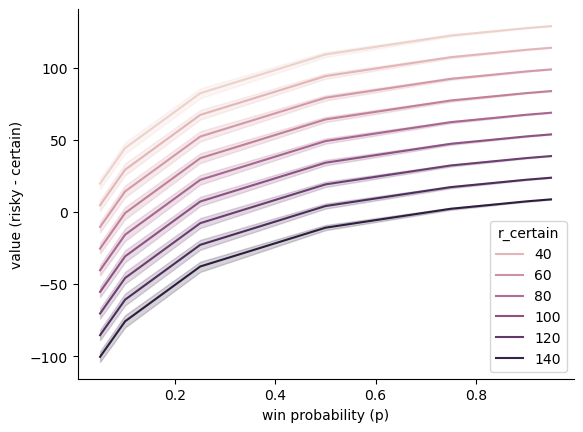

In [29]:
sns.lineplot(data=df, x='win probability (p)', y='value (risky - certain)', hue='r_certain')
sns.despine()

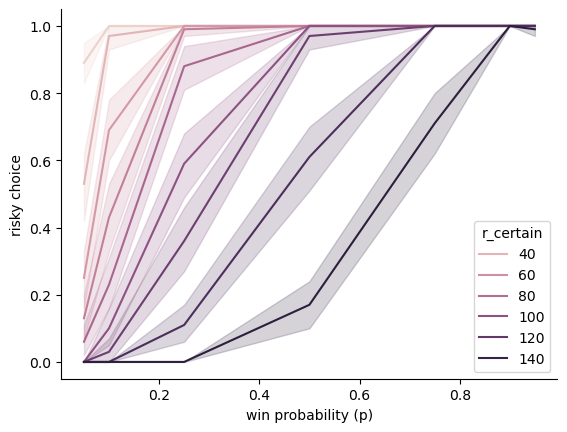

In [30]:
sns.lineplot(data=df, x='win probability (p)', y='risky choice', hue='r_certain')
sns.despine()

<hr width="100%" style="border-top: 3px solid; margin: 2em 0;">

## Effort Discounting

### Task

On every trial, the participant chooses between two options:

- **Low effort**: a **smaller** amount for minimal effort.
- **High effort**: a **larger, fixed** amount (\$155) requiring effort level
  $E$.

The same 9-trial ladder repeats at each of 7 effort levels,
`E = [1, 2, 3, 4, 5, 6, 7]` (arbitrary effort units, e.g. percent of maximum
grip force or required button-press count), for 7 blocks x 9 trials = 63
trials total per subject. `ED_PAYOUTS` fixes the high-effort reward at \$155
and steps the low-effort amount down from \$145 to \$25.

Only the **high-effort** reward is discounted; the low-effort amount requires
negligible effort and is not discounted.

Below, `payouts[trial, choice]` with `choice = 0` low_effort / `1`
high_effort.

### Model

Effort is discounted **parabolically** (an accelerating effort cost):

$$
V_{\text{low}} = r_{\text{low}} \quad\text{(undiscounted)}, \qquad V_{\text{high}}(E) = r_{\text{high}} - kE^2
$$

$$
p(\text{high\_effort}) = \sigma\big(V_{\text{high}} - V_{\text{low}}\big)
$$

Parabolic effort discounting (accelerating cost; cf. Prevost et al., 2010;
Hartmann et al., 2013). One model, one free parameter: `ed_par_k` ($k$, the
effort discount rate).

In [31]:
print(f"Model ID   : {ed_par_k_model.id}")
print(f"Description: {ed_par_k_model.desc}")
print(f"Spec       : {ed_par_k_model.spec}")

Model ID   : ed_par_k
Description: Parabolic effort discounting (accelerating effort cost, cf. Prevost,
Pessiglione, Metereau, Clery-Melin, & Dreher, 2010; Hartmann et al., 2013):
V_high(E) = r_high - k*E**2; the smaller low-effort option is undiscounted.
p(high_effort) = sigmoid(V_high - V_low).
Free parameter: k (effort discount rate, >0).
Spec       : {'effort_discounting': {'weight': [], 'discount': ['k']}, 'shape': 'parabolic', 'choice_rule': 'sigmoid(delta_V)'}


401.7932 (000), 101.7151 (001), 101.3121 (002), 101.2967 (003), 101.2958 (004), 

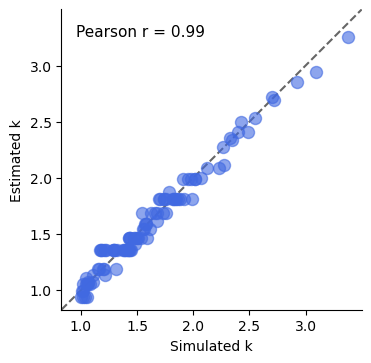

In [32]:
effort_levels = DEFAULT_EFFORT_LEVELS.copy()
ed_payouts = ED_PAYOUTS.copy()

# k*E**2 (E up to 7 -> E**2 up to 49) must sweep the low-effort ladder (~25-145).
kmin, kmax = 1.0, 3.5
true_k = draw_positive(nsubjects, kmin, kmax, loc=0.0, scale=1.0)
true_params = np.stack([true_k], axis=1)

sim = ed_par_k_model.sim(true_params, payouts=ed_payouts, effort_levels=effort_levels)
all_data = [[c, p, d] for c, p, d in zip(sim["choices"], sim["payouts"], sim["effort_levels"])]

model = EMModel(
    all_data=all_data,
    fit_func=ed_par_k_model.fit,
    param_names=["k"],
    param_xform=[norm2beta],
)

result = model.fit(verbose=1)

for param_idx, param_label in enumerate(["k"]):
    simulated_param = sim["params"][:, param_idx]
    estimated_param = model.outfit["params"][:, param_idx]
    ax = plotting.plot_scatter(simulated_param, f"Simulated {param_label}",
                                estimated_param, f"Estimated {param_label}")

Diagnostic plots: the fitted value difference ($\Delta V$ = high-effort
minus low-effort) and the choice rate for the high-effort option, as a
function of effort level $E$ and the low-effort option's own amount
$r_{\text{low}}$.

In [33]:
_, nblocks, ntrials = model.outfit['delta_V'].shape
df = pd.DataFrame({
    "subj_idx": np.repeat(np.arange(nsubjects), nblocks * ntrials),
    "effort level (E)": np.repeat(model.outfit['effort_levels'].reshape(-1), ntrials),
    "trial_idx": np.tile(np.arange(ntrials), nsubjects * nblocks),
    "value (high - low)": model.outfit['delta_V'].reshape(-1),
    "high-effort choice": model.outfit['choices_high'].reshape(-1),
    "r_low": np.tile(ED_PAYOUTS[:, 0], nsubjects * nblocks),
})

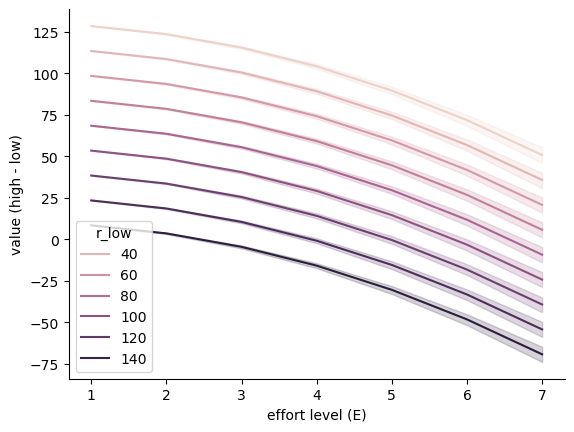

In [34]:
sns.lineplot(data=df, x='effort level (E)', y='value (high - low)', hue='r_low')
sns.despine()

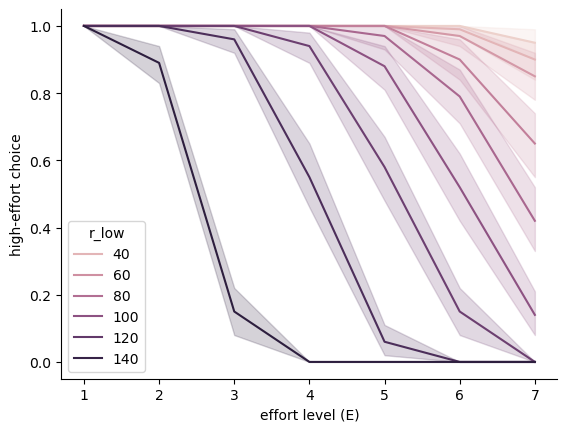

In [35]:
sns.lineplot(data=df, x='effort level (E)', y='high-effort choice', hue='r_low')
sns.despine()

<hr width="100%" style="border-top: 3px solid; margin: 2em 0;">

## Prosocial Effort Discounting

### Task

On every trial, the participant chooses between two options:

- **Low effort**: a **smaller** reward for the block's beneficiary, minimal
  effort.
- **High effort**: a **larger, fixed** reward (\$155) for the beneficiary,
  requiring effort level $E$.

Blocks come in two types, tagged by their **beneficiary**: on **self** blocks
the reward goes to the chooser, on **other** blocks it goes to a social
target. The chooser always exerts the effort; only the recipient differs.
The default design pairs the 7 effort levels `E = [1..7]` with each
beneficiary, giving 14 blocks x 9 trials = 126 trials per subject. This is
the self/other effort paradigm of Lockwood et al. (2017), where willingness
to work is typically discounted more steeply when the reward benefits someone
else.

Below, `payouts[trial, choice]` with `choice = 0` low_effort / `1`
high_effort (reward paid to the block's beneficiary), and a separate
`beneficiary` array with one entry per block (0 = self, 1 = other).

### Model

Effort is discounted **parabolically**, as in the effort-discounting model
above, but the discount **rate can differ by beneficiary**:

$$
V_{\text{high}}(E) = r_{\text{high}} - k_b E^2, \qquad
k_b = \begin{cases} k_{\text{self}} & \text{on self blocks} \\ k_{\text{other}} & \text{on other blocks} \end{cases}
$$

$$
p(\text{high\_effort}) = \sigma\big(V_{\text{high}} - V_{\text{low}}\big)
$$

Two nested models share this task:

| model | free parameters | |
|---|---|---|
| `ped_par_k`  | $k$ | one rate for both self and other blocks |
| `ped_par_2k` | $k_{\text{self}}$, $k_{\text{other}}$ | separate rate per beneficiary |

$k_{\text{other}} > k_{\text{self}}$ indicates steeper effort discounting when
helping others ("prosocial apathy").

#### Single rate ($k$) — `ped_par_k`

In [36]:
print(f"Model ID   : {ped_par_k_model.id}")
print(f"Description: {ped_par_k_model.desc}")
print(f"Spec       : {ped_par_k_model.spec}")

Model ID   : ped_par_k
Description: Parabolic prosocial effort discounting with a single discount rate:
V_high(E) = r_high - k*E**2, applied identically whether the reward benefits
self or other; the low-effort option is undiscounted.
p(high_effort) = sigmoid(V_high - V_low).
Free parameter: k (effort discount rate, >0).
Spec       : {'prosocial_effort_discounting': {'weight': [], 'discount': ['k']}, 'shape': 'parabolic', 'choice_rule': 'sigmoid(delta_V)'}


541.3202 (000), 231.2800 (001), 231.1799 (002), 231.1775 (004), 231.1774 (005), 

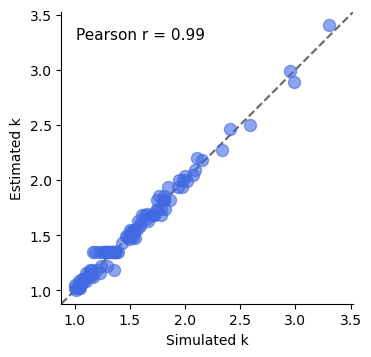

In [37]:
ped_effort_levels = PED_EFFORT_LEVELS.copy()   # 14 blocks: E=1..7 for self, then E=1..7 for other
beneficiary = PED_BENEFICIARY.copy()           # 0=self, 1=other, per block
ped_payouts = PED_PAYOUTS.copy()

kmin, kmax = 1.0, 3.5
true_k = draw_positive(nsubjects, kmin, kmax, loc=0.0, scale=1.0)
true_params = np.stack([true_k], axis=1)

sim = ped_par_k_model.sim(true_params, payouts=ped_payouts,
                          effort_levels=ped_effort_levels, beneficiary=beneficiary)
all_data = [[c, p, e, b] for c, p, e, b in
            zip(sim["choices"], sim["payouts"], sim["effort_levels"], sim["beneficiary"])]

model = EMModel(
    all_data=all_data,
    fit_func=ped_par_k_model.fit,
    param_names=["k"],
    param_xform=[norm2beta],
)

result = model.fit(verbose=1)

for param_idx, param_label in enumerate(["k"]):
    simulated_param = sim["params"][:, param_idx]
    estimated_param = model.outfit["params"][:, param_idx]
    ax = plotting.plot_scatter(simulated_param, f"Simulated {param_label}",
                                estimated_param, f"Estimated {param_label}")

Diagnostic plot: high-effort choice rate as a function of effort level $E$,
split by beneficiary. With a single shared $k$, the self and other curves
overlap (the model applies the same effort discounting either way).

In [38]:
_, nblocks, ntrials = model.outfit['delta_V'].shape
ben = np.repeat(model.outfit['beneficiary'].reshape(-1), ntrials)
df = pd.DataFrame({
    "subj_idx": np.repeat(np.arange(nsubjects), nblocks * ntrials),
    "effort level (E)": np.repeat(model.outfit['effort_levels'].reshape(-1), ntrials),
    "trial_idx": np.tile(np.arange(ntrials), nsubjects * nblocks),
    "value (high - low)": model.outfit['delta_V'].reshape(-1),
    "high-effort choice": model.outfit['choices_high'].reshape(-1),
    "beneficiary": np.where(ben == 0, "self", "other"),
})

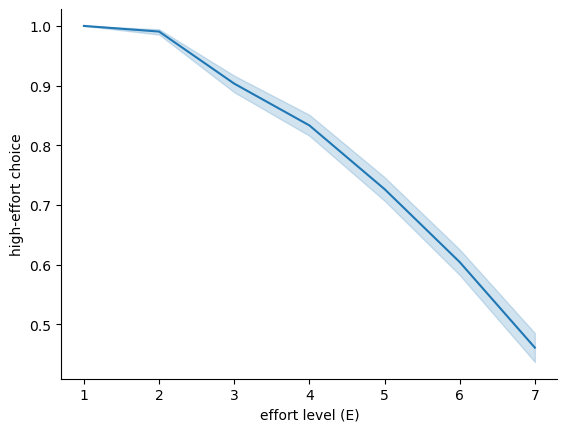

In [39]:
sns.lineplot(data=df, x='effort level (E)', y='high-effort choice')
sns.despine()

<hr width="80%">

#### Separate self/other rates ($k_{\text{self}}$, $k_{\text{other}}$) — `ped_par_2k`

Here we simulate each subject with independent $k_{\text{self}}$ and
$k_{\text{other}}$ (drawn from the same range) and recover both. To instead
illustrate the canonical "steeper for other" effect, draw `true_k_other` from
a higher range than `true_k_self`.

In [40]:
print(f"Model ID   : {ped_par_2k_model.id}")
print(f"Description: {ped_par_2k_model.desc}")
print(f"Spec       : {ped_par_2k_model.spec}")

Model ID   : ped_par_2k
Description: Parabolic prosocial effort discounting with separate self/other rates:
V_high(E) = r_high - k_b*E**2, where k_b = k_self on blocks whose reward
benefits the chooser and k_other on blocks whose reward benefits a social
target; the low-effort option is undiscounted.
p(high_effort) = sigmoid(V_high - V_low).
Free parameters: k_self (effort discount rate for self, >0), k_other (effort
discount rate for other, >0). k_other > k_self indicates steeper effort
discounting when helping others.
Spec       : {'prosocial_effort_discounting': {'weight': [], 'discount': ['k_self', 'k_other']}, 'shape': 'parabolic', 'choice_rule': 'sigmoid(delta_V)'}


852.7085 (000), 162.5010 (001), 160.9367 (002), 160.8531 (003), 160.8463 (004), 160.8444 (005), 160.8442 (006), 

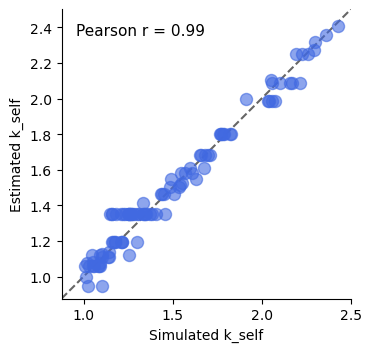

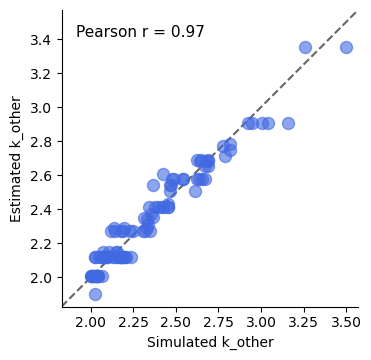

In [ ]:
kmin_self, kmax_self = 1.0, 2.5
kmin_other, kmax_other = 2.0, 4.5 # inflating k_other
true_k_self = draw_positive(nsubjects, kmin_self, kmax_self, loc=0.0, scale=1.0)
true_k_other = draw_positive(nsubjects, kmin_other, kmax_other, loc=0.0, scale=1.0)
true_params = np.stack([true_k_self, true_k_other], axis=1)

sim = ped_par_2k_model.sim(true_params, payouts=ped_payouts,
                           effort_levels=ped_effort_levels, beneficiary=beneficiary)
all_data = [[c, p, e, b] for c, p, e, b in
            zip(sim["choices"], sim["payouts"], sim["effort_levels"], sim["beneficiary"])]

model = EMModel(
    all_data=all_data,
    fit_func=ped_par_2k_model.fit,
    param_names=["k_self", "k_other"],
    param_xform=[norm2beta, norm2beta],
)

result = model.fit(verbose=1)

for param_idx, param_label in enumerate(["k_self", "k_other"]):
    simulated_param = sim["params"][:, param_idx]
    estimated_param = model.outfit["params"][:, param_idx]
    ax = plotting.plot_scatter(simulated_param, f"Simulated {param_label}",
                                estimated_param, f"Estimated {param_label}")

Diagnostic plot: high-effort choice rate versus effort level $E$, split by
beneficiary. Because `ped_par_2k` fits a separate rate per beneficiary, the
self and other curves can diverge (their spread reflects the fitted
$k_{\text{self}}$ vs $k_{\text{other}}$).

In [42]:
_, nblocks, ntrials = model.outfit['delta_V'].shape
ben = np.repeat(model.outfit['beneficiary'].reshape(-1), ntrials)
df = pd.DataFrame({
    "subj_idx": np.repeat(np.arange(nsubjects), nblocks * ntrials),
    "effort level (E)": np.repeat(model.outfit['effort_levels'].reshape(-1), ntrials),
    "trial_idx": np.tile(np.arange(ntrials), nsubjects * nblocks),
    "value (high - low)": model.outfit['delta_V'].reshape(-1),
    "high-effort choice": model.outfit['choices_high'].reshape(-1),
    "beneficiary": np.where(ben == 0, "self", "other"),
})

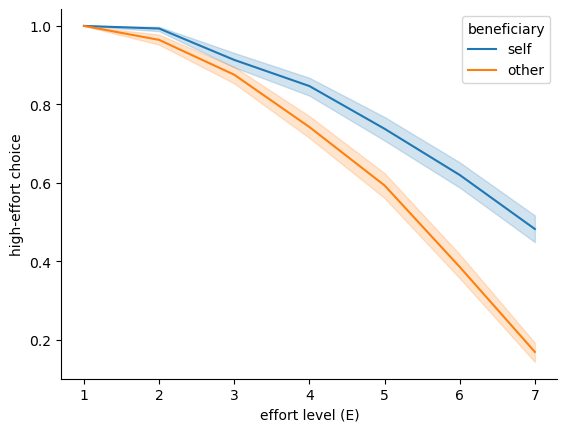

In [43]:
sns.lineplot(data=df, x='effort level (E)', y='high-effort choice', hue='beneficiary')
sns.despine()

**References**

Jones, B., & Rachlin, H. (2006). Social discounting. Psychological Science, 17(4), 283-286.

Rhoads, S. A., Vekaria, K. M., O'Connell, K., Elizabeth, H. S., Rand, D. G., Kozak Williams, M. N., & Marsh, A. A. (2023). Unselfish traits and social decision-making patterns characterize six populations of real-world extraordinary altruists. Nature Communications, 14(1), 1807.

Rhoads, S. A., O'Connell, K., Berluti, K., Ploe, M. L., Elizabeth, H. S., Amormino, P., ... & Marsh, A. A. (2023). Neural responses underlying extraordinary altruists' generosity for socially distant others. PNAS nexus, 2(7), pgad199.

Mazur, J. E. (1987). An adjusting procedure for studying delayed reinforcement. In M. L. Commons, J. E. Mazur, J. A. Nevin, & H. Rachlin (Eds.), Quantitative Analyses of Behavior: Vol. 5. The Effect of Delay and of Intervening Events on Reinforcement Value (pp. 55-73). Erlbaum.

Rachlin, H., Raineri, A., & Cross, D. (1991). Subjective probability and delay. Journal of the Experimental Analysis of Behavior, 55(2), 233-244.

Prevost, C., Pessiglione, M., Metereau, E., Clery-Melin, M. L., & Dreher, J. C. (2010). Separate valuation subsystems for delay and effort decision costs. Journal of Neuroscience, 30(42), 14080-14090.

Lockwood, P. L., Hamonet, M., Zhang, S. H., Ratnavel, A., Salmony, F. U., Husain, M., & Apps, M. A. J. (2017). Prosocial apathy for helping others when effort is required. Nature Human Behaviour, 1(7), 0131.